# Laptop Price Predictor — Part 4 of 4
### Train Test Split · Model Preparation · Model Accuracy · Cross_val function · cross_val Accuracy

| Part | Notebook | Assignment steps |
|---|---|---|
| 1 | `Part1_Data_Loading_and_Feature_Extraction.ipynb` | 1 Import Library · 2 Data Loading · 3 Feature Extraction · 4 Data Info |
| 2 | `Part2_Missing_Data_and_Duplicates.ipynb` | 5 Checking missing data · 6 Missing Data Treatment · 7 Duplicate Checking · 8 Duplicate Removing |
| 3 | `Part3_Visualization_and_Feature_Engineering.ipynb` | 9 Data Visualization · 10 Correlation with target · 11 Features and target separation · 12 Feature Selection · 13 Feature Scaling · 14 PCA · 15 Encoding |
| **4** | **`Part4_Model_Training_and_Cross_Validation.ipynb`** ← you are here | **16 Train Test Split · 17 Model Preparation · 18 Model Accuracy · 19 Cross_val function · 20 cross_val Accuracy** |

**Input:** `laptop_part3_model_ready.csv` (from Part 3)

**Running in Google Colab:** *Runtime → Run all*. Upload `laptop_part3_model_ready.csv` when asked.

## Setup: libraries and the Part 3 output

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from google.colab import files  # this import only works inside Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


def find_file(name):
    """Find a data file next to the notebook, in a data/ folder or in Colab's /content.
    In Colab, if the file is missing, ask for an upload."""
    for folder in [".", "data", "/content", "/content/data"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    if IN_COLAB:
        print(f"'{name}' was not found - please upload it.")
        uploaded = files.upload()
        return next(iter(uploaded))  # Colab saves the upload in /content
    raise FileNotFoundError(f"Put '{name}' next to this notebook (or in a data/ folder) and run again.")


def save_output(frame, name):
    """Save a CSV for the next part. In Colab the file is also downloaded so you can upload it there."""
    folder = "data" if os.path.isdir("data") else "."
    path = os.path.join(folder, name)
    frame.to_csv(path, index=False)
    print(f"Saved {path}  ->  {frame.shape[0]} rows x {frame.shape[1]} columns")
    if IN_COLAB:
        files.download(path)

# One quiet chart style for the whole project: recessive grid, data in color, text in ink.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, BLUE_LIGHT, ORANGE, RED = "#2a78d6", "#b7d3f6", "#eb6834", "#e34948"
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3de", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.prop_cycle": plt.cycler(color=SERIES), "font.size": 10, "figure.dpi": 100,
    "lines.linewidth": 2,
})
thousands = mticker.StrMethodFormatter("{x:,.0f}")


data = pd.read_csv(find_file("laptop_part3_model_ready.csv"))
X = data.drop(columns=["price"])
y = data["price"]

# Numeric features are scaled; 0/1 columns (encoded categories, Yes/No flags) are left as they are.
numeric_features = [c for c in X.columns if not set(X[c].unique()) <= {0, 1}]
print("Data:", data.shape, "  X:", X.shape, "  y:", y.shape)
print("Numeric features to scale:", numeric_features)

Data: (832, 32)   X: (832, 31)   y: (832,)
Numeric features to scale: ['ram_gb', 'ssd', 'hdd', 'os_bit', 'graphic_card_gb', 'display_inch']


## Step 16: Train Test Split

80% of the laptops train the models; the other 20% are held back to test them on laptops they have never seen.
`random_state=42` makes the split the same every time the notebook runs.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} laptops ({X_train.shape[0] / len(X):.0%})")
print(f"Test set    : {X_test.shape[0]} laptops ({X_test.shape[0] / len(X):.0%})")

pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(0)

Training set: 665 laptops (80%)
Test set    : 167 laptops (20%)


,train,test
count,665.0,167.0
mean,77823.0,74958.0
std,48061.0,41873.0
min,17490.0,13990.0
25%,46990.0,45490.0
50%,63990.0,64990.0
75%,92990.0,87990.0
max,441990.0,225990.0


Both sets have a similar price range and average, so the test set is a fair sample.

## Step 17: Model Preparation

Every model is a **pipeline**: the preprocessing (scaling, and PCA for one model) is part of the model, so it
is fitted on the training data only — on `fit()` here and inside each fold in cross-validation.

| Model | How it predicts |
|---|---|
| Linear Regression | price = weighted sum of the features (a straight-line relationship) |
| PCA + Linear Regression | the same, but on principal components (Step 14) of all scaled features, keeping 95% of the variance |
| Decision Tree | a series of yes/no questions about the features (max depth 8 to limit overfitting) |
| Random Forest | the average of 300 decision trees, each trained on a random sample |
| Gradient Boosting | trees added one at a time, each correcting the errors of the previous ones |

In [3]:
def scale_numeric():
    """Scale numeric columns and pass the 0/1 columns through unchanged."""
    return ColumnTransformer([("scale", StandardScaler(), numeric_features)], remainder="passthrough")


models = {
    "Linear Regression": Pipeline([
        ("scale", scale_numeric()),
        ("model", LinearRegression()),
    ]),
    "PCA + Linear Regression": Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("model", LinearRegression()),
    ]),
    "Decision Tree": Pipeline([
        ("scale", scale_numeric()),
        ("model", DecisionTreeRegressor(max_depth=8, random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scale", scale_numeric()),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("scale", scale_numeric()),
        ("model", GradientBoostingRegressor(random_state=42)),
    ]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

n_pca = models["PCA + Linear Regression"].named_steps["pca"].n_components_
print(f"\nPCA kept {n_pca} of {X.shape[1]} columns to explain 95% of the variance.")

Trained: Linear Regression
Trained: PCA + Linear Regression
Trained: Decision Tree


Trained: Random Forest
Trained: Gradient Boosting

PCA kept 23 of 31 columns to explain 95% of the variance.


## Step 18: Model Accuracy

For a regression model (predicting a number, not a class), accuracy is measured with:

- **R² score** — the main "accuracy" for regression: 1.0 = perfect, 0 = no better than always guessing the
  average price. Compared on the **training** and **test** sets: a big gap means the model memorised the
  training data (*overfitting*).
- **MAE** — mean absolute error: on average, how far the predicted price is from the real price.
- **RMSE** — root mean squared error: like MAE, but large mistakes count more.
- **Within ±20%** — share of test laptops whose predicted price is within 20% of the real price.

In [4]:
rows = []
for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    rows.append({
        "model": name,
        "train R2": r2_score(y_train, train_pred),
        "test R2": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "within ±20%": np.mean(np.abs(test_pred - y_test) / y_test <= 0.20) * 100,
    })

accuracy = pd.DataFrame(rows).set_index("model").sort_values("test R2", ascending=False)
accuracy.style.format({"train R2": "{:.3f}", "test R2": "{:.3f}", "MAE": "{:,.0f}",
                       "RMSE": "{:,.0f}", "within ±20%": "{:.1f}%"})

,train R2,test R2,MAE,RMSE,within ±20%
model,,,,,
Gradient Boosting,0.814,0.652,"16,335","24,622",61.1%
Linear Regression,0.646,0.631,"18,116","25,375",48.5%
PCA + Linear Regression,0.525,0.500,"22,459","29,518",42.5%
Decision Tree,0.856,0.462,"18,278","30,620",59.3%
Random Forest,0.933,0.455,"17,521","30,810",59.3%


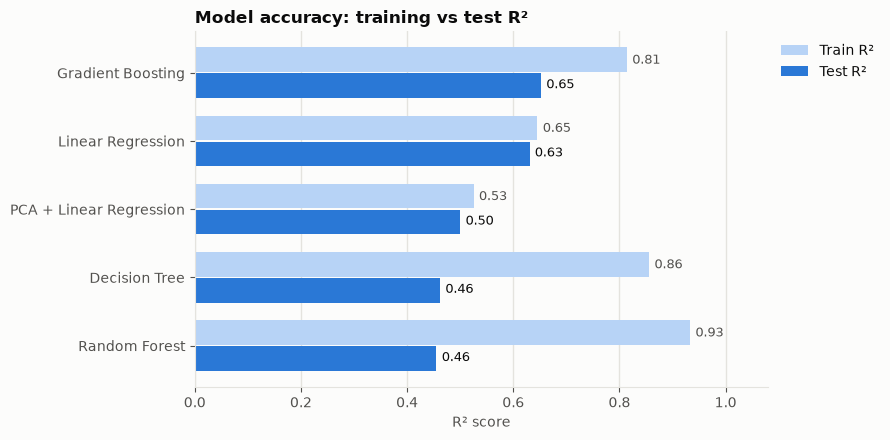

In [5]:
order = accuracy.sort_values("test R2").index
ypos = np.arange(len(order))
bar_h = 0.36

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ypos + bar_h / 2 + 0.01, accuracy.loc[order, "train R2"], height=bar_h, color=BLUE_LIGHT, label="Train R²")
ax.barh(ypos - bar_h / 2 - 0.01, accuracy.loc[order, "test R2"], height=bar_h, color=BLUE, label="Test R²")
for y_, (tr, te) in enumerate(zip(accuracy.loc[order, "train R2"], accuracy.loc[order, "test R2"])):
    ax.text(tr + 0.01, y_ + bar_h / 2, f"{tr:.2f}", va="center", color=INK_2, fontsize=9)
    ax.text(te + 0.01, y_ - bar_h / 2, f"{te:.2f}", va="center", color=INK, fontsize=9)
ax.set_yticks(ypos, order)
ax.set_xlim(0, 1.08)
ax.set_xlabel("R² score")
ax.set_title("Model accuracy: training vs test R²")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

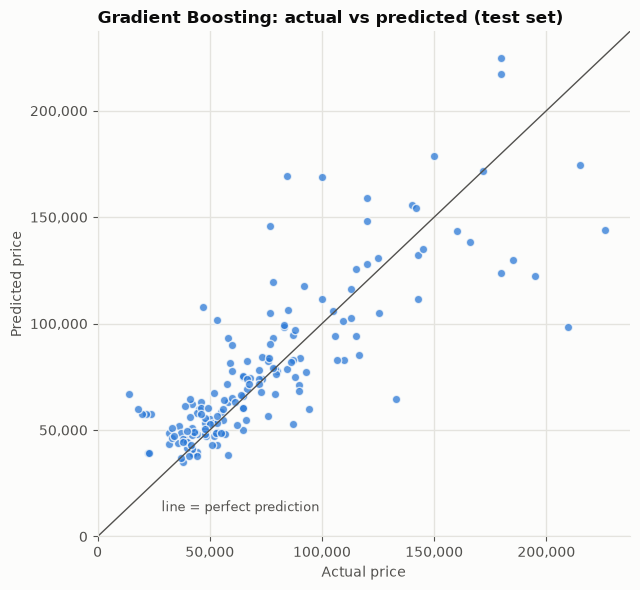

In [6]:
best_name = accuracy.index[0]
best_pred = models[best_name].predict(X_test)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, best_pred, s=36, color=BLUE, alpha=0.75, edgecolors=SURFACE, linewidths=1)
limit = [0, max(y_test.max(), best_pred.max()) * 1.05]
ax.plot(limit, limit, color=INK_2, linewidth=1)
ax.text(limit[1] * 0.12, limit[1] * 0.05, "line = perfect prediction", color=INK_2, fontsize=9)
ax.set_xlim(limit)
ax.set_ylim(limit)
ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.xaxis.set_major_formatter(thousands)
ax.yaxis.set_major_formatter(thousands)
ax.set_title(f"{best_name}: actual vs predicted (test set)")
plt.tight_layout()
plt.show()

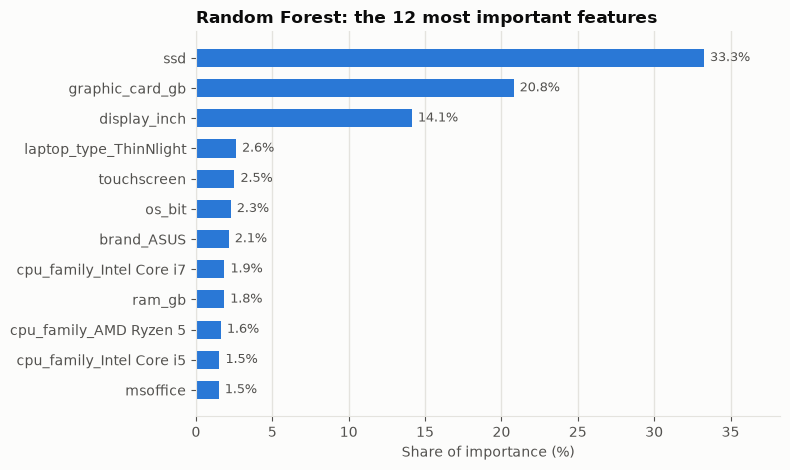

In [7]:
forest = models["Random Forest"].named_steps["model"]
feature_names = models["Random Forest"].named_steps["scale"].get_feature_names_out()
feature_names = [n.split("__", 1)[1] for n in feature_names]           # drop the "scale__" prefix
importance = pd.Series(forest.feature_importances_, index=feature_names).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(importance.index, importance * 100, color=BLUE, height=0.6)
for y_, v in enumerate(importance * 100):
    ax.text(v + 0.4, y_, f"{v:.1f}%", va="center", color=INK_2, fontsize=9)
ax.set_title("Random Forest: the 12 most important features")
ax.set_xlabel("Share of importance (%)")
ax.set_xlim(0, importance.max() * 100 * 1.15)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

- **Gradient Boosting** has the best test accuracy: **R² = 0.652**, an average error (MAE) of about 16,300, and
  61% of test laptops predicted within ±20% of their real price.
- **Linear Regression** is close behind (R² 0.631), and its train and test scores are almost equal (0.646 vs
  0.631): it does not overfit.
- **Decision Tree** and **Random Forest** score very well on the training data (0.86 and 0.93) but only about
  0.46 on the test set: they **overfit**, memorising the training laptops.
- **PCA + Linear Regression** is worse than plain Linear Regression (0.500 vs 0.631). PCA kept 23 of the 31
  columns, and the variance it dropped still carried price information.
- `ssd` and `graphic_card_gb` are the Random Forest's most important features, matching the correlation check in
  Part 3. `display_inch` comes third: it helps in combination with other features even though its own
  correlation with price is weak.

## Step 19: Cross_val function

One train/test split can be lucky or unlucky. **K-fold cross-validation** splits the data into 5 parts (folds);
each fold is the test set once while the other 4 train the model. The 5 scores show how stable the accuracy is.

In [8]:
def cross_val(model, X, y, folds=5, show=True):
    """Return the R² score of `model` on each of `folds` cross-validation folds."""
    kfold = KFold(n_splits=folds, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")
    if show:
        print("R² per fold:", np.round(scores, 3))
        print(f"Mean R²    : {scores.mean():.3f}   (std {scores.std():.3f})")
    return scores


# Example: cross-validate Linear Regression
lr_scores = cross_val(models["Linear Regression"], X, y)

R² per fold: [0.631 0.538 0.582 0.561 0.678]
Mean R²    : 0.598   (std 0.050)


## Step 20: cross_val Accuracy

In [9]:
cv_scores = {}
for name, model in models.items():
    print(f"--- {name} ---")
    cv_scores[name] = cross_val(model, X, y)
    print()

--- Linear Regression ---
R² per fold: [0.631 0.538 0.582 0.561 0.678]
Mean R²    : 0.598   (std 0.050)

--- PCA + Linear Regression ---


R² per fold: [0.5   0.444 0.47  0.392 0.543]
Mean R²    : 0.470   (std 0.051)

--- Decision Tree ---
R² per fold: [0.462 0.31  0.622 0.445 0.413]
Mean R²    : 0.450   (std 0.101)

--- Random Forest ---


R² per fold: [0.467 0.606 0.777 0.586 0.581]
Mean R²    : 0.603   (std 0.100)

--- Gradient Boosting ---


R² per fold: [0.651 0.639 0.73  0.475 0.564]
Mean R²    : 0.612   (std 0.087)



In [10]:
cv_table = pd.DataFrame({
    "mean R2": {n: s.mean() for n, s in cv_scores.items()},
    "std": {n: s.std() for n, s in cv_scores.items()},
    "min": {n: s.min() for n, s in cv_scores.items()},
    "max": {n: s.max() for n, s in cv_scores.items()},
}).sort_values("mean R2", ascending=False)
cv_table["test R2 (Step 18)"] = accuracy["test R2"]
cv_table.round(3)

,mean R2,std,min,max,test R2 (Step 18)
Gradient Boosting,0.612,0.087,0.475,0.730,0.652
Random Forest,0.603,0.100,0.467,0.777,0.455
Linear Regression,0.598,0.050,0.538,0.678,0.631
PCA + Linear Regression,0.470,0.051,0.392,0.543,0.500
Decision Tree,0.450,0.101,0.310,0.622,0.462


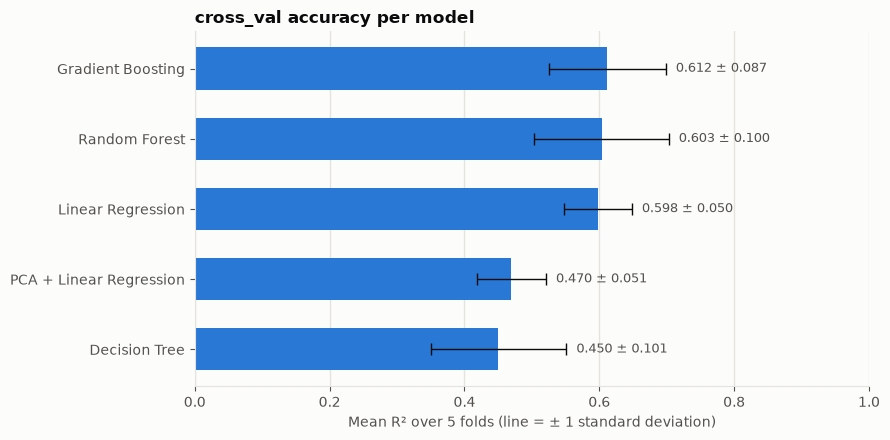

In [11]:
plot_cv = cv_table.sort_values("mean R2")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_cv.index, plot_cv["mean R2"], color=BLUE, height=0.6)
ax.errorbar(plot_cv["mean R2"], np.arange(len(plot_cv)), xerr=plot_cv["std"], fmt="none",
            ecolor=INK, elinewidth=1, capsize=4)
for y_, (m, s) in enumerate(zip(plot_cv["mean R2"], plot_cv["std"])):
    ax.text(m + s + 0.015, y_, f"{m:.3f} ± {s:.3f}", va="center", color=INK_2, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("Mean R² over 5 folds (line = ± 1 standard deviation)")
ax.set_title("cross_val accuracy per model")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Predictions for a few test laptops

In [12]:
final_name = cv_table.index[0]
final_model = models[final_name]

sample = X_test.head(10)
predicted = pd.DataFrame({
    "actual price": y_test.loc[sample.index],
    "predicted price": final_model.predict(sample),
})
predicted["error %"] = (predicted["predicted price"] - predicted["actual price"]) / predicted["actual price"] * 100
print("Model:", final_name)
predicted.style.format({"actual price": "{:,.0f}", "predicted price": "{:,.0f}", "error %": "{:+.1f}%"})

Model: Gradient Boosting


,actual price,predicted price,error %
610,"58,100","93,382",+60.7%
819,"57,990","38,491",-33.6%
290,"64,990","74,892",+15.2%
559,"142,990","132,317",-7.5%
168,"82,990","98,418",+18.6%
687,"119,990","148,148",+23.5%
818,"94,190","59,971",-36.3%
86,"52,990","42,990",-18.9%
260,"41,990","62,211",+48.2%
547,"66,490","69,113",+3.9%


## Conclusion

- **Data preparation mattered most.** Hidden missing values (`"Missing"`, 0-inch screens, non-RAM values…) and
  10 duplicate rows were fixed, and 34 messy processor names became 10 CPU families.
- **What drives price:** SSD size, graphics card memory and brand (Apple and MSI are the most expensive).
- **Best model:** after 5-fold cross-validation, **Gradient Boosting** (mean R² **0.612** ± 0.087), just ahead of
  Random Forest (0.603) and Linear Regression (0.598). Linear Regression is the most stable (std 0.050).
- **What R² ≈ 0.6 means:** the models explain about 60% of the price differences between laptops. The rest comes
  from information the data does not contain, or that was scraped into the wrong column (for example CPU
  families whose prices do not follow CPU power).
- **Why cross-validation:** for Random Forest, the single test split (Step 18) gave 0.455, but cross-validation
  gave 0.603. One split can be lucky or unlucky; the cross_val accuracy is the more reliable number.

**Possible improvements:** tune the model settings with `GridSearchCV`, predict `log(price)` to reduce the
effect of the very expensive laptops, and collect cleaner data for the processor and RAM columns.